In [1]:
import sys
sys.path.append('..')
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from matplotlib.image import imread
from matplotlib.gridspec import GridSpec
import scipy
from scipy import stats

import config
import data_processing

import warnings
warnings.filterwarnings('ignore')

In [2]:
def scene_to_screen_coordinates(scene_coordinate):
    scene_x, scene_y = scene_coordinate
    scene_x_lim = 800
    scene_y_lim = 1000
    screen_x_lim = 1920
    screen_y_lim = 1080
    converted_x = screen_x_lim/2 - scene_x_lim/2 + scene_x
    converted_y = screen_y_lim/2 - scene_y_lim/2 + scene_y
    return [converted_x, converted_y]

In [3]:
def expand_trajectory_dataframe(df):
    """
    Expands a dataframe containing trajectory data into a long format.

    Returns a dataframe where each row represents a single timestep,
    with the coordinates unpacked into separate x,y columns.
    """
    # Create lists to store our expanded data
    expanded_data = {
        'scene_name': [],
        'sample_idx': [],
        'x': [],
        'y': [],
        'trajectory_idx': [],
        'reasoning_trace': []
    }
    
    # Iterate through each row (simulation run) in the original dataframe
    for _, row in df.iterrows():
        # Get the current simulation's data
        trajectory = row['trajectory']
        indices = row['trajectory_idx']
        reasoning = row['reasoning_trace']
        try:
            sample_idx = row['sample_idx']
        except KeyError:
            sample_idx = 0
        
        # Get number of timesteps in this simulation
        n_steps = len(trajectory)
        
        # Verify that all lists have matching lengths
        if not (len(trajectory) == len(indices) == len(reasoning)):
            raise ValueError(
                f"Mismatch in list lengths for scene '{row['scene_name']}', "
                f"simulation {sample_idx}:\n"
                f"trajectory: {len(trajectory)}, "
                f"indices: {len(indices)}, "
                f"reasoning: {len(reasoning)}"
            )
        
        # Add scene name and simulation index for each timestep
        expanded_data['scene_name'].extend([row['scene_name']] * n_steps)
        expanded_data['sample_idx'].extend([sample_idx] * n_steps)
        
        # Extract and add x,y coordinates
        x_coords, y_coords = zip(*trajectory)
        expanded_data['x'].extend(x_coords)
        expanded_data['y'].extend(y_coords)
        
        # Add trajectory indices and reasoning traces
        expanded_data['trajectory_idx'].extend(indices)
        expanded_data['reasoning_trace'].extend(reasoning)
    
    # Create the new dataframe
    expanded_df = pd.DataFrame(expanded_data)
    
    return expanded_df

In [4]:
def interpolate_trajectory_dataframe(df):
    """
    Interpolates an already expanded trajectory dataframe from 60Hz to 1000Hz.

    Returns a dataframe where each row represents a single timestep at 1000Hz,
    with interpolated coordinates and load values.
    """
    # Create lists to store our interpolated data
    interpolated_data = {
        'scene_name': [],
        'sample_idx': [], 
        'x': [],
        'y': [],
        'trajectory_idx': [],
        'reasoning_trace': [],
        'load': []
    }
    
    # Process each scene/sample combination separately
    for (scene, sample), group in df.groupby(['scene_name', 'sample_idx']):
        # Get number of timesteps in this simulation
        n_steps = len(group)
        
        # Create time arrays for interpolation
        t_orig = np.linspace(0, n_steps/60, n_steps)  # Original 60Hz timing
        t_interp = np.linspace(0, n_steps/60, int(n_steps * 1000/60))  # New 1000Hz timing
        
        # Get original coordinates
        x_coords = group['x'].values
        y_coords = group['y'].values
        
        # Interpolate coordinates to 1000Hz using cubic interpolation
        from scipy.interpolate import CubicSpline
        x_interp = CubicSpline(t_orig, x_coords)(t_interp)
        y_interp = CubicSpline(t_orig, y_coords)(t_interp)
        
        # Interpolate indices and reasoning (using nearest neighbor since these should be discrete)
        indices_interp = np.interp(t_interp, t_orig, group['trajectory_idx'].values).round().astype(int)
        reasoning_interp = [group['reasoning_trace'].values[np.abs(t_orig - t).argmin()] for t in t_interp]
        
        # Get number of interpolated timesteps
        n_steps_interp = len(t_interp)
        
        # Add scene name and simulation index for each timestep
        interpolated_data['scene_name'].extend([scene] * n_steps_interp)
        interpolated_data['sample_idx'].extend([sample] * n_steps_interp)
        
        # Add interpolated coordinates
        interpolated_data['x'].extend(x_interp)
        interpolated_data['y'].extend(y_interp)
        
        # Add interpolated trajectory indices and reasoning traces
        interpolated_data['trajectory_idx'].extend(range(len(x_interp)))
        interpolated_data['reasoning_trace'].extend(reasoning_interp)
        
        # Add load values, preserving original values at sample points and setting interpolated values
        load_values = []
        for i, t in enumerate(t_interp):
            # Find if this is an original sample point
            is_original = any(np.abs(t - t_orig) < 1e-10)
            if is_original:
                # Use high for original points
                load_values.append('high')
            else:
                # For interpolated points, set based on reasoning_trace
                if reasoning_interp[i] == 'simulation':
                    load_values.append('high')
                elif reasoning_interp[i] == 'abstraction':
                    load_values.append('low')
                else:
                    raise ValueError(f"Unknown reasoning trace: {reasoning_interp[i]}")
        interpolated_data['load'].extend(load_values)
    
    # Create the new dataframe
    interpolated_df = pd.DataFrame(interpolated_data)
    
    return interpolated_df

In [5]:
def expand_abstraction(df, T=10):
    # Create new dataframe to store expanded data
    expanded_rows = []
    
    # Iterate through rows
    for i in range(len(df)):
        row = df.iloc[i]
        # Add current row
        expanded_rows.append(row.copy())
        # If this is an abstraction row, interpolate points
        if row['reasoning_trace'] == 'abstraction' and i > 0:
            prev_row = df.iloc[i-1]
            # Calculate step sizes
            x_step = (row['x'] - prev_row['x']) / (T + 1)
            y_step = (row['y'] - prev_row['y']) / (T + 1)  # Create interpolated points
            for t in range(T):
                interp_row = row.copy()
                interp_row['x'] = prev_row['x'] + (t + 1) * x_step
                interp_row['y'] = prev_row['y'] + (t + 1) * y_step
                expanded_rows.append(interp_row)
    # Convert back to dataframe
    result = pd.DataFrame(expanded_rows)
    # Recompute trajectory indices as cumulative count per scene
    result['trajectory_idx'] = result.groupby(['scene_name', 'sample_idx']).cumcount()
    return result

Blended mode data

In [6]:
# Get human gaze data
human_gaze_data = data_processing.get_human_data(
    data_dir=os.path.join('..', config.DATA_DIR, 'experiment1'), include='both')

Processing ASC files:   0%|          | 0/12 [00:00<?, ?it/s]

Processing ASC files: 100%|██████████| 12/12 [00:18<00:00,  1.51s/it]


In [7]:
# Get blended model predictions
with open(os.path.join('..', config.DATA_DIR, 'blended_results.json'), 'r') as f:
    blended_model_predictions_dict = json.load(f)
blended_model_data = pd.DataFrame.from_dict(blended_model_predictions_dict)

In [8]:
# Expand the blended model data for different T values
T_values = [1]
blended_model_dfs = []

for T in T_values:
    df = blended_model_data.copy()
    df = interpolate_trajectory_dataframe(expand_abstraction(expand_trajectory_dataframe(df)))
    df['T'] = T
    blended_model_dfs.append(df)

blended_model_data = pd.concat(blended_model_dfs, ignore_index=True)

In [9]:
# Map blended model coordinates to screen coordinates
blended_model_data[['x', 'y']] = blended_model_data.apply(
    lambda row: scene_to_screen_coordinates((row['x'], row['y'])), 
    axis=1,
    result_type='expand'
)

Simulation model data

In [10]:
# Get simulation model predictions
simulation_data = data_processing.get_simulation_model_predictions(
    os.path.join('..',config.DATA_DIR, 'simulation_results.json'))
simulation_data = expand_trajectory_dataframe(simulation_data)

In [11]:
# Map blended model coordinates to screen coordinates
simulation_data[['x', 'y']] = simulation_data.apply(
    lambda row: scene_to_screen_coordinates((row['x'], row['y'])), 
    axis=1,
    result_type='expand'
)

In [12]:
from scipy.stats import wasserstein_distance, gaussian_kde
emd_distances = []
# Number of points to sample from each KDE
n_samples = 5000
for bw in [0.1, 0.2, 0.3, 0.4, 0.5, 1, 1.5, 2]:
    for scene in sorted(human_gaze_data.scene_name.unique()):
        # Get data for this scene
        scene_blended = blended_model_data[(blended_model_data.scene_name == scene)]
        scene_simulation = simulation_data[simulation_data.scene_name == scene]
        subject_gaze = human_gaze_data[(human_gaze_data.scene_name == scene)]
        scene_accuracy = human_gaze_data[human_gaze_data.scene_name == scene].mean_acc_scene.mean()
        response_time = human_gaze_data[human_gaze_data.scene_name == scene].trial_duration_zscore.mean()
        try:
            # Estimate KDE for model data with Scott's rule bandwidth estimation
            kde_blended = gaussian_kde(scene_blended[['x', 'y']].T, bw_method=bw)
            kde_simulation = gaussian_kde(scene_simulation[['x', 'y']].T, bw_method=bw)
            # Estimate KDE for fixation data
            kde_gaze = gaussian_kde(subject_gaze[['x', 'y']].T, bw_method=bw)
        except np.linalg.LinAlgError:
            print(f"Skipping scene {scene} due to LinAlgError")
            continue
        # Sample points from the KDEs
        samples_blended = kde_blended.resample(n_samples).T
        samples_simulation = kde_simulation.resample(n_samples).T    
        samples_gaze = kde_gaze.resample(n_samples).T
        # Compute 2D EMD for simulation vs empirical
        sim_emd = wasserstein_distance(
            samples_simulation.flatten(),
            samples_gaze.flatten()
        )
        # Compute 2D EMD for blended model vs empirical 
        model_emd = wasserstein_distance(
            samples_blended.flatten(),
            samples_gaze.flatten()
        )
        emd_distances.extend([
            {
                'scene': scene,
                'model_type': 'Simulation',
                'emd': sim_emd,
                'scene_accuracy': scene_accuracy,
                'response_time': response_time,
                'bw': bw
            },
            {
                'scene': scene,
                'model_type': 'Blended', 
                'emd': model_emd,
                'scene_accuracy': scene_accuracy,
                'response_time': response_time,
                'bw': bw
            }
        ])
    # Convert to dataframe
    fixation_emd_df = pd.DataFrame(emd_distances)

Skipping scene low_nocol_yessp_1 due to LinAlgError
Skipping scene low_nocol_yessp_4 due to LinAlgError
Skipping scene low_yescol_yessp_1 due to LinAlgError
Skipping scene low_yescol_yessp_4 due to LinAlgError
Skipping scene med_nocol_yessp_2 due to LinAlgError
Skipping scene scene_1_10 due to LinAlgError
Skipping scene scene_1_6 due to LinAlgError
Skipping scene scene_2_12 due to LinAlgError
Skipping scene scene_2_23 due to LinAlgError
Skipping scene scene_2_8 due to LinAlgError
Skipping scene scene_2_9 due to LinAlgError
Skipping scene low_nocol_yessp_1 due to LinAlgError
Skipping scene low_nocol_yessp_4 due to LinAlgError
Skipping scene low_yescol_yessp_1 due to LinAlgError
Skipping scene low_yescol_yessp_4 due to LinAlgError
Skipping scene med_nocol_yessp_2 due to LinAlgError
Skipping scene scene_1_10 due to LinAlgError
Skipping scene scene_1_6 due to LinAlgError
Skipping scene scene_2_12 due to LinAlgError
Skipping scene scene_2_23 due to LinAlgError
Skipping scene scene_2_8 due t

In [13]:
# Remove scenes containing 'high_nocol_yessp'
fixation_emd_df = fixation_emd_df[~fixation_emd_df['scene'].str.contains('high_nocol_yessp')]

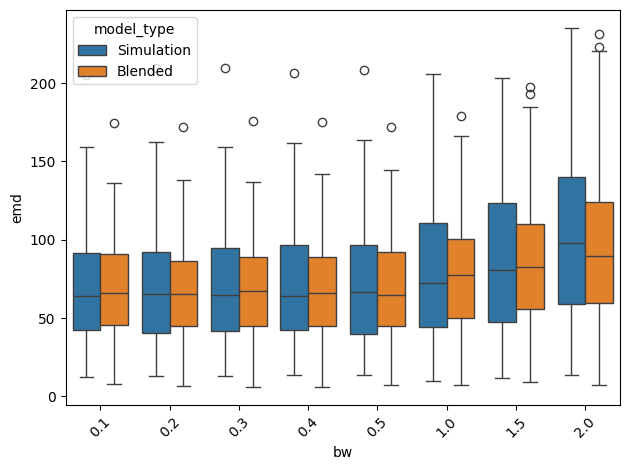

In [14]:
g = sns.boxplot(data=fixation_emd_df, x='bw', y='emd', hue='model_type')
plt.xticks(rotation=45)
plt.tight_layout()

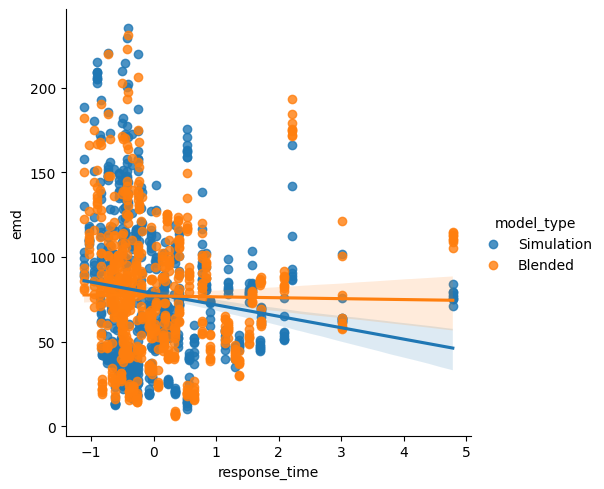

In [19]:
sns.lmplot(data=fixation_emd_df, x='response_time', y='emd', hue='model_type')